# Installing required Libraries 
    -> pandas
    -> seaborn (matplotlib)
    -> numpy
    

In [2]:
!pip install pandas

In [3]:
!pip install numpy 
!pip install seaborn

# Steps to be done 
- Read CSV
- Check for null values 
- Plot relations between variables
- Design model



In [4]:
import seaborn as sb
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd #import pandas to read csv and handle the data
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [8]:
df = pd.read_csv("../data/water_data.csv") # GroundWater sample training data set

In [9]:
df.head()

,tank_capacity,current_level,residents,daily_usage,rainfall,season,days_left
0,10700,1018,36,4307.298198,6.478662,winter,0.24
1,12672,9100,50,6724.696205,7.484769,summer,1.35
2,8618,3725,19,2928.959925,7.045614,winter,1.27
3,5613,2537,24,3461.914197,8.365875,summer,0.73
4,12041,8849,28,3528.505924,6.299878,summer,2.51


In [10]:
df.describe()

,tank_capacity,current_level,residents,daily_usage,rainfall,days_left
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,12713.965000,7005.641000,27.976000,3881.624207,5.147733,2.807900
std,4318.504797,4248.320807,13.533535,2038.642050,2.879322,3.402469
min,5048.000000,1015.000000,5.000000,467.548211,0.000144,0.130000
25%,9070.000000,3714.500000,16.000000,2203.924990,2.725214,0.900000
50%,12866.000000,6033.000000,28.000000,3740.123715,5.339205,1.705000
75%,16517.750000,9883.000000,40.000000,5389.828872,7.625616,3.220000
max,19957.000000,19366.000000,50.000000,9869.820252,9.997389,29.160000


## Checking for NULL values

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   tank_capacity  1000 non-null   int64  
 1   current_level  1000 non-null   int64  
 2   residents      1000 non-null   int64  
 3   daily_usage    1000 non-null   float64
 4   rainfall       1000 non-null   float64
 5   season         1000 non-null   object 
 6   days_left      1000 non-null   float64
dtypes: float64(3), int64(3), object(1)
memory usage: 54.8+ KB


### No null values are present, therefore continuing to find relationship 

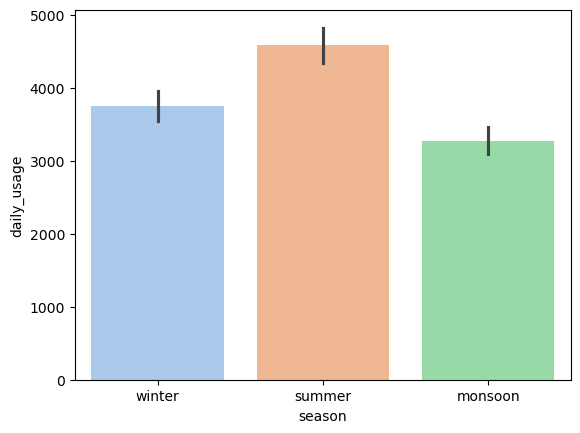

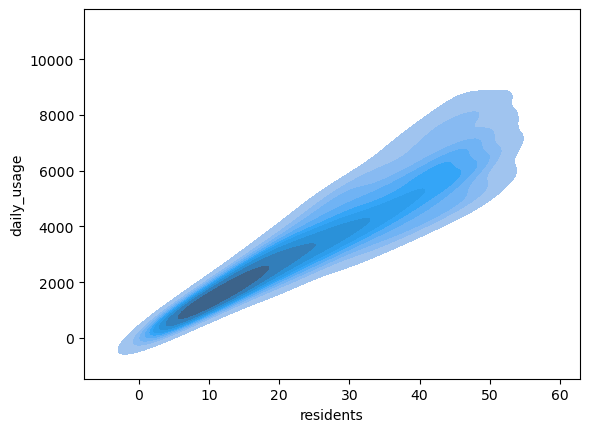

In [12]:
plt.figure()
sb.barplot(df,y='daily_usage',x='season',palette="pastel",capsize=None)
plt.show()

plt.figure()
sb.kdeplot(data=df, x='residents',y='daily_usage', fill=True)
plt.show()

<Axes: >

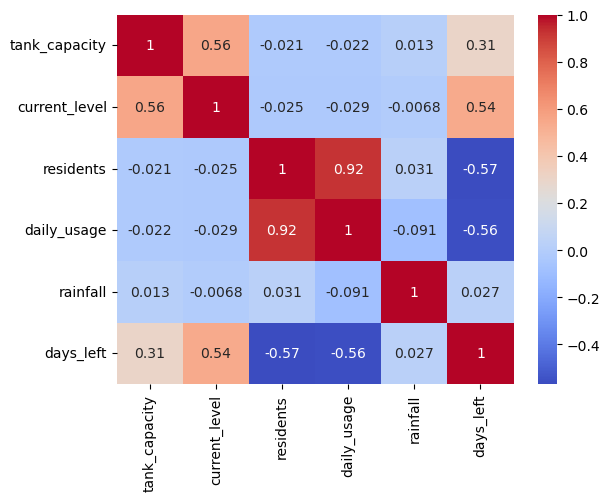

In [13]:
corr = df.corr(numeric_only=True)
sb.heatmap(corr, annot=True, cmap='coolwarm')

## From the above observations we can infer that 
* Season affect daily usage
* Residents and daily_usage are +ve highly correlated
* Residents and daily usage are -ve correlated

In [14]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [15]:
from sklearn.datasets import make_regression
from sklearn.linear_model import Ridge

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split 
#splits data into training data(to learn) and testing data(to check performance of model)

from sklearn.ensemble import RandomForestRegressor
#A simple ML model

In [16]:
X = df[["tank_capacity", "current_level", "residents", "daily_usage", "rainfall"]] #The inputs given to the model (Question to the model)

In [17]:
y = df["days_left"] #What needs to be predicted (Answer the model should give for the question)

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [19]:
model = RandomForestRegressor(random_state=42)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [20]:
y_pred = model.predict(X_test)

In [21]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

MAE: 0.2117405
R² Score: 0.9757157242086443


In [22]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)

print(scores)
print("Average:", scores.mean())

[0.95325846 0.97225063 0.99455917 0.98576955 0.99174934]
Average: 0.9795174290450619


In [23]:
import pickle   # Saves the trained model into a file

pickle.dump(model, open("model.pkl", "wb"))

In [24]:
print(type(model))

<class 'sklearn.ensemble._forest.RandomForestRegressor'>


tank_capacity: 0.008
current_level: 0.388
residents: 0.026
daily_usage: 0.572
rainfall: 0.006
